In [1]:
from brian2 import *
sys.path.append('Neuron and Synapse Models')
from neuronModels import *
from ringAttractorTEMP import *

In [2]:
# Simulation parameters
defaultclock.dt = 0.1*ms

In [3]:
# Setting network parameters
num_neurons = 120
tau=10*ms
sigma_noise=1*mV
V_rest=-70*mV

In [4]:
# External input: a spatially modulated current.
positions = linspace(0, 2*pi, num_neurons, endpoint=False)


# For example, we define a Gaussian input centered at a particular position (stimulus_center)
stimulus_center = pi/2  # center of the bump on the ring
stimulus_width = 0.5  # width in radians
I0 = 20*mV         # amplitude of the external input

# Define the external input as a function of neuron position
I_ext_array = I0 * exp(-((positions - stimulus_center)**2) / (2 * stimulus_width**2))
# You might also add a time-dependence if desired. Here we assume a constant stimulus during the simulation.

In [5]:
# Creating the equation object
neuron_eq = Equations(LIF_xi_eq, tau=tau, V_rest=V_rest, sigma_noise=sigma_noise)

In [6]:
# Create neuron group
Vth=-48*mV
V_reset=-80*mV
refractory_period=5*ms

ringAttractor = RingAttractor(LIF_xi_eq, 
                 num_neurons, 
                 Vth, V_reset, refractory_period,
                 # Choose connectivity profile: 'mexican_hat', 'gaussian', or 'cosine'
                 syn_profile='mexican_hat',
                 autapse=True)
ringAttractor.ring_pool.I_ext = I_ext_array

In [7]:
# Setup monitors: spike monitor and state monitor for membrane potential and external input
spikemon = SpikeMonitor(ringAttractor.ring_pool)
statemon = StateMonitor(ringAttractor.ring_pool, 'V', record=True)
inputmon = StateMonitor(ringAttractor.ring_pool, 'I_ext', record=True)  # if you want to check the input

net = Network(ringAttractor.BrianObjects + [spikemon, statemon, inputmon])
print("List of network objects: ", net.objects)
# Run the simulation
duration = 500*ms
net.run(duration)

List of network objects:  {NeuronGroup(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='ring_neurons'), Synapses(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='ring_synapses'), <StateMonitor, recording ['I_ext'] from 'ring_neurons'>, <SpikeMonitor, recording from 'spikemonitor'>, <StateMonitor, recording ['V'] from 'ring_neurons'>}


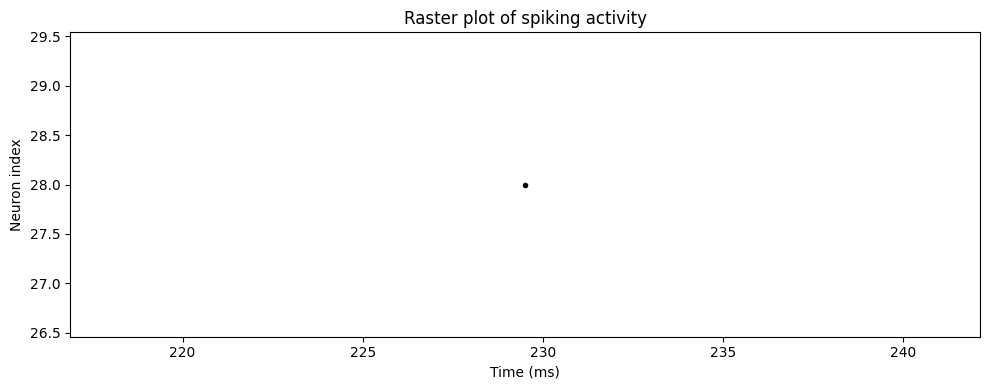

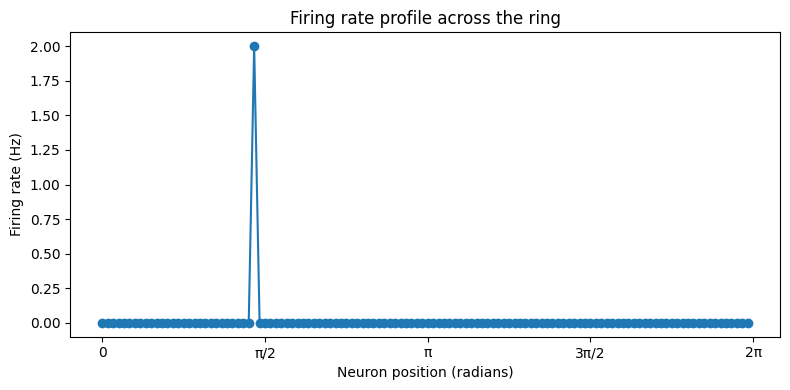

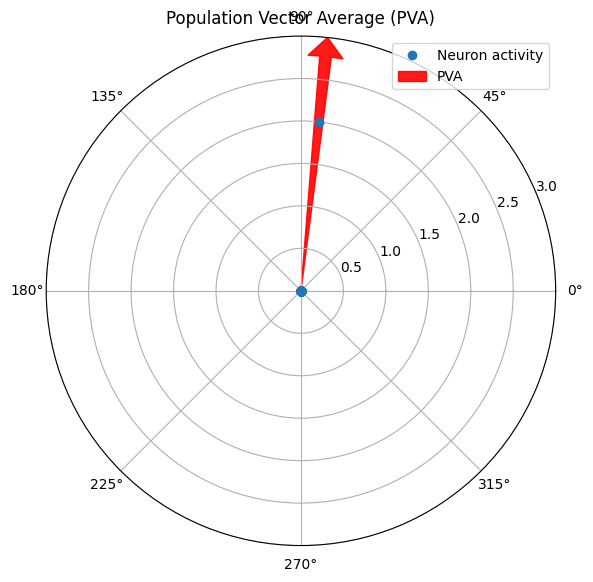

NameError: name 'N' is not defined

In [8]:
# ---------------------
# 1. Raster Plot
# ---------------------
plt.figure(figsize=(10, 4))
plt.plot(spikemon.t/ms, spikemon.i, '.k')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Raster plot of spiking activity')
plt.tight_layout()
plt.show()

# ---------------------
# 2. Firing Rate Profile
# ---------------------
# Compute firing rate per neuron (spike count divided by simulation duration)
spike_counts = spikemon.count / duration  # in Hz (since duration is in seconds)
plt.figure(figsize=(8, 4))
plt.plot(positions, spike_counts, 'o-', color='tab:blue')
plt.xlabel('Neuron position (radians)')
plt.ylabel('Firing rate (Hz)')
plt.title('Firing rate profile across the ring')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.tight_layout()
plt.show()

# ---------------------
# 3. Polar Plot of the Population Vector Average (PVA)
# ---------------------
# Compute the PVA: circular mean weighted by spike counts
weighted_sum = np.sum(spike_counts/Hz * np.exp(1j * positions))
pva_angle = np.angle(weighted_sum)
pva_magnitude = np.abs(weighted_sum) / np.sum(spike_counts)  # normalized (0 to 1)

# Set a scaling factor so the arrow is clearly visible.
# Here we choose scale_factor to be a multiple of the maximum firing rate.
scale_factor = 1.5 * max(spike_counts)

plt.figure(figsize=(6,6))
ax = plt.subplot(111, projection='polar')
# Plot each neuron's activity as a marker at its position.
ax.plot(positions, spike_counts, 'o', label='Neuron activity', color='tab:blue')
# Plot the PVA arrow: starting at the center (r=0), with angle pva_angle, and length scaled.
ax.arrow(pva_angle, 0, 0, pva_magnitude * scale_factor, width=0.05, 
         color='r', label='PVA', alpha=0.9, length_includes_head=True)
# Set radial limit to display the arrow clearly.
ax.set_rlim(0, scale_factor)
ax.set_title('Population Vector Average (PVA)', va='bottom')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ---------------------
# 4. Time-Resolved PVA
# ---------------------
# Define a sliding window for time-resolved analysis
window_size = 50*ms   # window length for PVA computation
step_size = 10*ms
num_windows = int((duration - window_size) / step_size) + 1
pva_time = []
pva_angles = []

# Compute the PVA for each time window
time_windows = np.arange(0, float(duration/ms) - float(window_size/ms) + 1, float(step_size/ms)) * ms

for t_start in time_windows:
    t_end = t_start + window_size
    # Get indices of spikes within this window
    indices = (spikemon.t >= t_start) & (spikemon.t < t_end)
    # Count spikes per neuron in the window
    spikes_window = np.zeros(N)
    for neuron_idx in spikemon.i[indices]:
        spikes_window[neuron_idx] += 1
    # Compute weighted circular sum if there is any activity
    if np.sum(spikes_window) > 0:
        weighted_sum_win = np.sum(spikes_window * np.exp(1j * positions))
        angle = np.angle(weighted_sum_win)
    else:
        angle = np.nan
    # Store the middle of the window and the computed angle
    pva_time.append((t_start + window_size/2)/ms)
    pva_angles.append(angle)

plt.figure(figsize=(10, 4))
plt.plot(pva_time, pva_angles, '-o', color='tab:green')
plt.xlabel('Time (ms)')
plt.ylabel('Bump center (radians)')
plt.title('Time-resolved Population Vector Average')
plt.yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.tight_layout()
plt.show()
